## 4.5. GBM (Gradient Boosting Machine)

✅ GBM을 이용한 사용자 행동 데이터 세트 예측 분류 

In [5]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
    feature_dup_df = feature_dup_df .reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x: x[0]+'_'+str(x[1])if x[1]>0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [7]:
import pandas as pd

def get_human_dataset():
    # 각 데이터 파일은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
    feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+', header=None, names=['colum_index', 'column_name'])

    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame 생성
    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    # Data Frame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:,1].values.tolist()

    # 학습 피처 데이터 세트와 테스트 피처 데이터를 DataFrame으로 로딩, 칼럼명은 feature_name 적용
    X_train = pd.read_csv('./human_activity/train/X_train.txt', sep='\s+', names=feature_name)
    X_test = pd.read_csv('./human_activity/test/X_test.txt', sep='\s+', names=feature_name)

    # 학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩하고 칼럼명은 action으로 부여
    y_train = pd.read_csv('./human_activity/train/y_train.txt', sep='\s+', header=None, names=['action'])
    y_test = pd.read_csv('./human_activity/test/y_test.txt', sep='\s+', header=None, names=['action'])

    # 로드된 학습/테스트용 DataFrame을 모두 반환 
    return X_train, X_test, y_train, y_test

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도 : {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간 : {0:.4f} 초'.format(time.time()-start_time))

GBM 정확도 : 0.9376
GBM 수행 시간 : 916.7854 초


➡️ 기본 파라미터만으로 랜덤 포레스트보다 나은 예측 성능을 나태냄 - 일반적으로 뛰어난 경우가 많음<br>
➡️ 그러나 수행 시간이 더 오래 걸리며, 하이퍼 파라미터 튜닝도 필요 <br>

## 4.6. XGBoost(eXtra Gradient Boost)

✅ XGBoost 설치 확인

In [10]:
import xgboost as xgb
from xgboost import XGBClassifier

In [11]:
print(xgb.__version__)

2.1.1


✅ 파이썬 래퍼 XGBoost 적용 - 위스콘신 유방암 예측

위스콘신 유방암 데이터는 다양한 속성값을 기반으로 해당 종양이 악성(malignant)인지 양성 종양(benign)인지를 분류한 데이터 세트 <br>
종양은 양성 / 악성 종양으로 구분<br>
-> 양성 종양 : 비교적 성장 속도가 느리고 전이가 안됨<br>
-> 악성 종양 : 주위조직에 침입하며 빠르게 성장하고 확산되어 생명을 위협

- DataFrame 로드 후 확인

In [12]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns=dataset.feature_names)
cancer_df['target'] = labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


➡️ 종양의 크기와 모양에 관련된 속성들이 숫자형 값으로 되어있음<br>
➡️ 타깃 레이블의 경우, 악성인 'malignant'가 0으로, 양성인 'benign'이 1값으로 되어있음 

- 레이블 값 분포 확인

In [46]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


➡️ 양성이 357개, 악성이 212개로 구성 

- 데이터 분할

In [19]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번재 칼럼까지를 :-1 슬라이싱으로 추출
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:,-1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


➡️ 전체 569개의 데이터 세트에서 최종 학습용 409개, 검증용 46개, 테스트용 1114개가 추출

- DataFrame 기반의 학습 데이터 세트와 테스트 데이터 세트를 DMatrix로 변환

In [21]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안 될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatrix를 생성
dtr = xgb.DMatrix(data=X_tr.values, label=y_tr)
dval = xgb.DMatrix(data=X_val.values, label=y_val)
dtest = xgb.DMatrix(data=X_test.values, label=y_test)

- XGBoost 하이퍼파라미터 설정

In [23]:
params = {'max_depth':3,
          'eta':0.05,
          'objective':'binary:logistic',
          'eval_metric':'logloss'
         }
num_rounds = 400

➡️ 트리 최대 깊이는 3 <br>
➡️ 학습률은 0.1 (XGBClassifier 사용할 경우엔 learning_rate)<br>
➡️ 예제 데이터가 0또는 1의 이진 분류이므로 목적함수는 이진 로지스틱(binary:logistic)<br>
➡️ 오류함수의 평가(val) 성능 지표는 logloss<br>
➡️ 부스팅 반복 횟수는 400회 

- 학습수행<br>
평가용 데이터 세트는 학습과 평가용 데이터 세트를 명기하는 튜플을 가지는 리스트 형태로 설정 <br>
=> Xgboost 학습 반복시마다 evals에 설정된 데이터 세트에 대해 평가 지표 결과를 출력

In [25]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기
eval_list = [(dtr,'train'),(dval,'eval')] # 또는 eval_list = [(dval, 'eval')]만 명기해도 무방.

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params = params, dtrain=dtr, num_boost_round=num_rounds,
                     early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.62480	eval-logloss:0.63104
[1]	train-logloss:0.58674	eval-logloss:0.60478
[2]	train-logloss:0.55226	eval-logloss:0.58223
[3]	train-logloss:0.52086	eval-logloss:0.56184
[4]	train-logloss:0.49192	eval-logloss:0.54118
[5]	train-logloss:0.46537	eval-logloss:0.52223
[6]	train-logloss:0.44029	eval-logloss:0.50287
[7]	train-logloss:0.41666	eval-logloss:0.48620
[8]	train-logloss:0.39525	eval-logloss:0.46974
[9]	train-logloss:0.37542	eval-logloss:0.45497
[10]	train-logloss:0.35701	eval-logloss:0.44131
[11]	train-logloss:0.33982	eval-logloss:0.43134
[12]	train-logloss:0.32297	eval-logloss:0.41972
[13]	train-logloss:0.30725	eval-logloss:0.40902
[14]	train-logloss:0.29327	eval-logloss:0.39883
[15]	train-logloss:0.27946	eval-logloss:0.38968
[16]	train-logloss:0.26691	eval-logloss:0.38150
[17]	train-logloss:0.25473	eval-logloss:0.37368
[18]	train-logloss:0.24385	eval-logloss:0.36666
[19]	train-logloss:0.23338	eval-logloss:0.35994
[20]	train-logloss:0.22320	eval-logloss:0.35374
[2

➡️ 지속적으로 train-logloss와 eval-logloss가 감소하고 있음 <br>
➡️ 127~176번까지 최저점에서 향상되지 않아서 early stop <br>
➡️ 학습이 완료된 모델 객체를 반환 <br>
 

- 테스트 데이터 세트에 예측 수행<br>
예측을 위해 predict() 메서드 이용 <br>

In [29]:
pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정하여 List 객체에 저장
preds = [1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.75  0.049 0.98  1.    0.999 0.999 0.998 0.001]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


➡️ 사이킷런과 달리, 예측 결과값이 아닌 예측 결과를 추정할 수 있는 확률 값을 반환 <br>
➡️ 0.5를 기준으로 예측 값을 결정하는 로직을 추가

- 성능 평가

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도 : {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [33]:
get_clf_eval(y_test, preds, pred_probs)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도 : 0.9740, 재현율: 0.9740,    F1: 0.9740, AUC: 0.9965


- xgboost 패키지의 시각화 기능 수행

`plot_importance()` API는 피처의 중요도를 막대그래프 형식으로 나타냄 <br>
f스코어(해당 피처가 트리 분할 시 얼마나 자주 사용되었는지)를 평가 지표로 사용해 중요도를 계산 

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

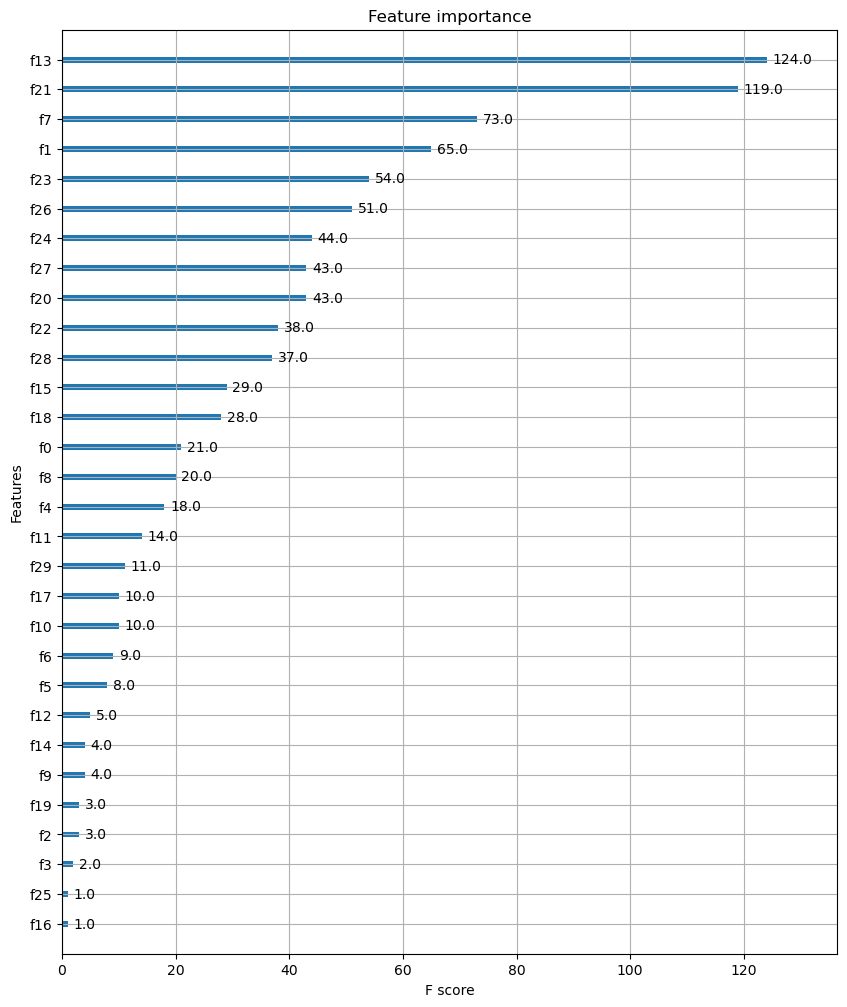

In [35]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12)) 
plot_importance(xgb_model, ax=ax) # 학습이 완료된 모델 객체, 맷플롯립의 ax 객체를 입력

➡️ xgboost를 DataFrame이 아닌 넘파이 기반의 피처 데이터로 학습시, 넘파이에서 피처명을 알 수 없으므로 Y축의 피처면은 피처 순서별로 f 뒤에 숫자가 붙음

✅ 사이킷런 래퍼 XGBoost 적용

하이퍼 파라미터는 파이썬 XGBoost와 동일하게 설정 
- 학습, 예측 후 성능평가

In [37]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metirc값을 XGBClassifier 생성 인자로 입력
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, eval_metric='logloss')
xgb_wrapper.fit(X_train.values, y_train, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

In [39]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차 행렬
[[35  2]
 [ 1 76]]
정확도: 0.9737, 정밀도 : 0.9744, 재현율: 0.9870,    F1: 0.9806, AUC: 0.9954


➡️ 파이썬 XGBoost보다 더 좋은 결과를 얻음 - 위스콘신 데이터 세트의 수가 적은데, 앞에선 early stopping사용으로 val데이터 분리하면서 더 작아졌기 때문으로 추정 

- 조기 중단 수행 및 성능 평가

조기 중단 관련 파라미터를 fit()에 입력하면 됨 

In [53]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, eval_metric="logloss", early_stopping_rounds = 50)
evals = [(X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr,  eval_set=evals, verbose=True)

ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

[0]	validation_0-logloss:0.63104
[1]	validation_0-logloss:0.60478
[2]	validation_0-logloss:0.58223
[3]	validation_0-logloss:0.56184
[4]	validation_0-logloss:0.54118
[5]	validation_0-logloss:0.52223
[6]	validation_0-logloss:0.50287
[7]	validation_0-logloss:0.48620
[8]	validation_0-logloss:0.46974
[9]	validation_0-logloss:0.45497
[10]	validation_0-logloss:0.44131
[11]	validation_0-logloss:0.43134
[12]	validation_0-logloss:0.41972
[13]	validation_0-logloss:0.40902
[14]	validation_0-logloss:0.39883
[15]	validation_0-logloss:0.38968
[16]	validation_0-logloss:0.38150
[17]	validation_0-logloss:0.37368
[18]	validation_0-logloss:0.36666
[19]	validation_0-logloss:0.35994
[20]	validation_0-logloss:0.35374
[21]	validation_0-logloss:0.34704
[22]	validation_0-logloss:0.34206
[23]	validation_0-logloss:0.33621
[24]	validation_0-logloss:0.33178
[25]	validation_0-logloss:0.32774
[26]	validation_0-logloss:0.32297
[27]	validation_0-logloss:0.31855
[28]	validation_0-logloss:0.31495
[29]	validation_0-loglos

➡️ 조기 종료 된 것을 확인 가능

In [55]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도 : 0.9740, 재현율: 0.9740,    F1: 0.9740, AUC: 0.9961


➡️ 약간 저조해짐 <br>

- early_stopping_rounds를 10으로 설정하고 예측 성능 다시 측정

In [62]:
# early_stopping_rounds를 10으로 설정하고 재학습
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, eval_metric="logloss", early_stopping_rounds = 10)
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)

ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test, ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.63104
[1]	validation_0-logloss:0.60478
[2]	validation_0-logloss:0.58223
[3]	validation_0-logloss:0.56184
[4]	validation_0-logloss:0.54118
[5]	validation_0-logloss:0.52223
[6]	validation_0-logloss:0.50287
[7]	validation_0-logloss:0.48620
[8]	validation_0-logloss:0.46974
[9]	validation_0-logloss:0.45497
[10]	validation_0-logloss:0.44131
[11]	validation_0-logloss:0.43134
[12]	validation_0-logloss:0.41972
[13]	validation_0-logloss:0.40902
[14]	validation_0-logloss:0.39883
[15]	validation_0-logloss:0.38968
[16]	validation_0-logloss:0.38150
[17]	validation_0-logloss:0.37368
[18]	validation_0-logloss:0.36666
[19]	validation_0-logloss:0.35994
[20]	validation_0-logloss:0.35374
[21]	validation_0-logloss:0.34704
[22]	validation_0-logloss:0.34206
[23]	validation_0-logloss:0.33621
[24]	validation_0-logloss:0.33178
[25]	validation_0-logloss:0.32774
[26]	validation_0-logloss:0.32297
[27]	validation_0-logloss:0.31855
[28]	validation_0-logloss:0.31495
[29]	validation_0-loglos

➡️ 더 낮아...져야하는데 왜 높아졌을까요..?

- 피처 중요도 시각화

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

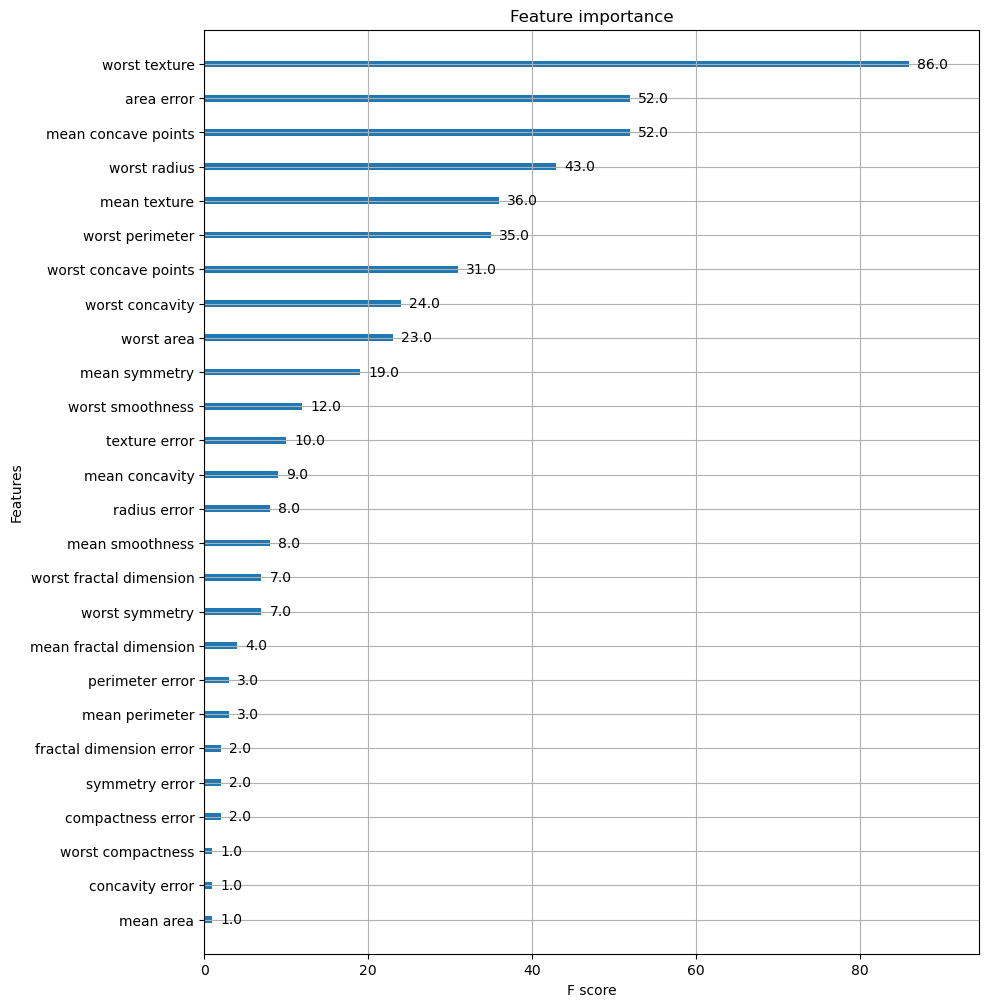

In [64]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
# 사이킷런 래퍼 클래스를 입력해도 무방
plot_importance(xgb_wrapper, ax=ax)

## 4.7. LightGBM

✅ LigthGBM 설치 확인

In [73]:
import lightgbm
from lightgbm import LGBMClassifier

✅ LigthGBM 적용 - 위스콘신 유방암 예측
<br>
LightGBM도 XGBoost와 동일하게 조기 중단 가능 

In [97]:
# LightGBM의 파이썬 패키지인 Lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증요 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05, early_stopping_rounds=50)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능 
evals = [(X_tr, y_tr), (X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr, eval_set=evals, eval_metric="logloss")
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000783 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training un

In [99]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도 : 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC: 0.9877


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

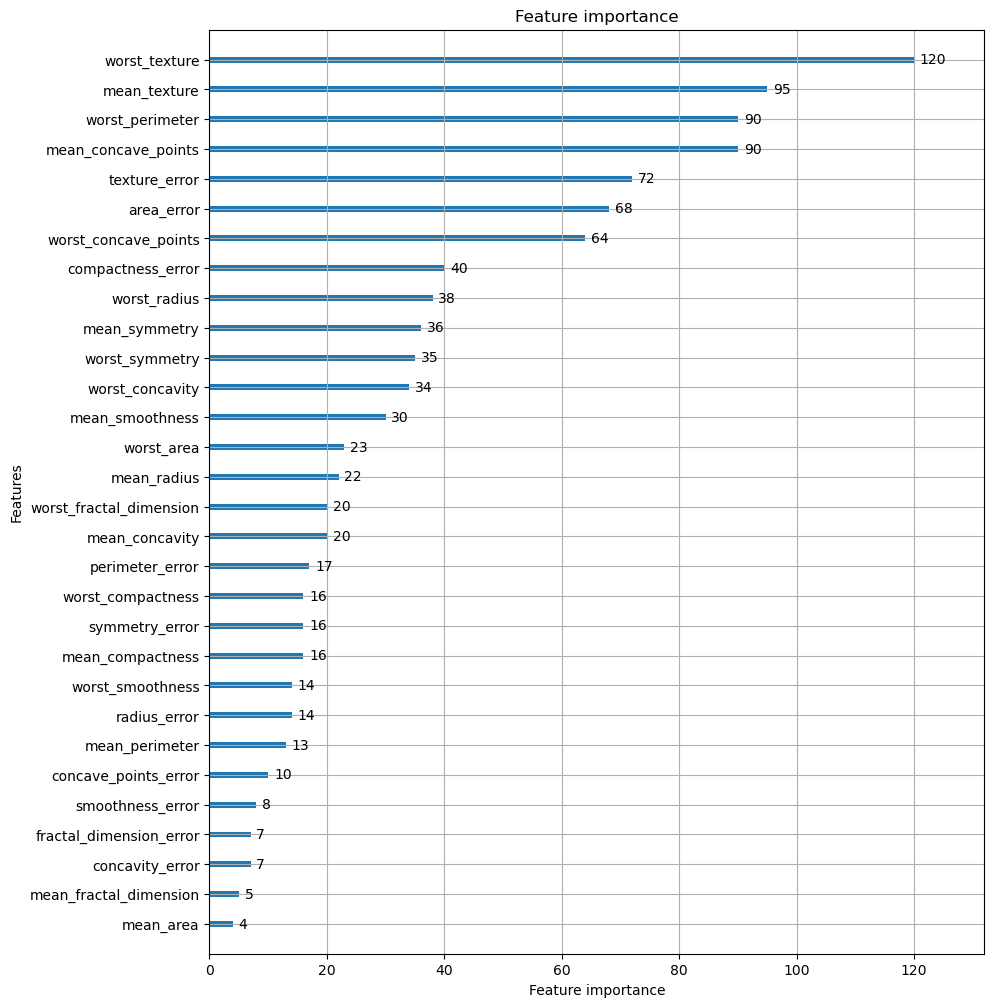

In [101]:
# plot_imortance()를 이용하여 feature중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)

## 4.8. 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝

✅ HyperOpt 사용하기 <br>

- hp 모듈을 이용하여 입력 변수명과 입력값의 검색 공간 설정하기
  <br>: 파이썬 딕셔너리 형태로 설정 (key는 입력변수명, value는 해당 입력 변수의 검색 공간)

In [54]:
from hyperopt import hp

# -10 ~ 10까지 1간격을 가지는 입력 변수 x와 -15 ~ 15까지 1간격으로 입력 변수 y 설정
search_space = {'x':hp.quniform('x',-10,10,1), 'y':hp.quniform('y',-15,15,1)}

➡️ 입력 변수 x는 -10 ~ 10까지 1의 간격을 가지는 값들, [-10, -9, ... , 8, 9, 10]을 가진다 (순차적으로 입력되지는 않음)

- 목적 함수 생성<br>
  : 변숫값과 검색공간을 가지는 딕셔너리를 인자로 -> 특정 값을 반환하는 구조 

In [56]:
from hyperopt import STATUS_OK

# 목적 함수를 생성. 변숫값과 변수 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환
def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2 - 20*y

    return retval

➡️ 검색공간 딕셔너리에서 x, y값을 추출하여 계산된 값을 반환 <br>
➡️ 딕셔너리 형태로 반환도 가능 ( `{'loss': retval, 'status':STATUS_OK}`와 같이 키값 설정 필요 )

In [58]:
from hyperopt import fmin, tpe, Trials
import numpy as np
# 입력 결괏값을 저장한 Trials 객체값 생성
trial_val = Trials()

# 목적 함수의 최솟값을 반환하는 최적 입력 변수값을 5번의 입력값 시도(max_evals=5)로 찾아냄.
best_01 = fmin(fn=objective_func, space=search_space, algo = tpe.suggest, max_evals=5,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_01)

100%|█████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 823.38trial/s, best loss: -224.0]
best: {'x': -4.0, 'y': 12.0}


➡️ $x^2 - 20y$ 반환값을 최소로 만드는 x, y 값을 반환 

- max_evals값을 20으로 설정

In [32]:
trial_val = Trials()

# max_evals를 20회로 늘려서 재테스트
best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=20, trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:',best_02)

100%|███████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 279.30trial/s, best loss: -296.0]
best: {'x': 2.0, 'y': 15.0}


➡️ 20회의 반복만으로 일정 수준의 최적값을 근사 가능 > 시간 감소 효과 

In [35]:
# fmin()에 인자로 들어가는 Trials 객체의 result 속성에 파이썬 리스트로 목적 함수 반환값들이 저장됨
# 리스트 내부의 개별 원소는 {'loss':함수 반환값, 'status':반환 상태값}와 같은 딕셔너리
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


➡️ 20회 반복을 수행했으므로 loss와 status를 키값으로 가지는 20개의 딕셔너리를 개별 원소로 가지는 리스트

In [38]:
# Trials객체의 vals 속성에 {'입력변수명' : 개별 수행 시마다 입력된 값 리스트} 형태로 저장됨 
print(trial_val.vals)

{'x': [-6.0, -4.0, 4.0, -4.0, 9.0, 2.0, 10.0, -9.0, -8.0, -0.0, -0.0, 1.0, 9.0, 6.0, 9.0, 2.0, -2.0, -4.0, 7.0, -0.0], 'y': [5.0, 10.0, -2.0, 12.0, 1.0, 15.0, 7.0, -10.0, 0.0, -5.0, -3.0, 2.0, 4.0, 10.0, 3.0, 3.0, -14.0, -8.0, 11.0, -0.0]}


➡️ vals는 딕셔너리 형태의 값을 가지며, 각 반복수행 마다 사용된 입력값들을 리스트 형태로 가지고 있음

- 속성값들을 DataFrame으로 만들어서 직관적으로 확인

In [43]:
import pandas as pd

# result에서 loss 키값에 해당하는 밸류들을 추출하여 list로 생성
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

# DataFrame으로 생성
result_df = pd.DataFrame({'x':trial_val.vals['x'], 'y':trial_val.vals['y'], 'losses':losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


✅ HyperOpt를 이용한 XGBoost 하이퍼 파라미터 최적화

- 특정 하이퍼 파라미터들은 정숫값만 입력을 받는데 hyperopt는 입력값과 반환 값이 모두 실수형이여서 형 변환이 필요
- hyperopt의 목적 함수는 최솟값을 반환 -> 값이 클수록 좋은 성능 지표일 경우 -1을 곱해주어야함 

- 데이터세트 로딩, 분리

In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증요 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

- 하이퍼파라미터 검색 공간 설정 

In [9]:
from hyperopt import hp

# max_depth는 5에서 20까지 1간격으로, min_child_weight는 1에서 2까지 1간격으로 
# colsample_bytree는 0.5에서 1 사이, learning_rate는 0.01에서 0.2사이 정규분포된 값으로 검색
xgb_search_space = {'max_depth':hp.quniform('max_depth',5,20,1),
                    'min_child_weight':hp.quniform('min_child_weight',1,2,1),
                    'learning_rate':hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree':hp.uniform('colsample_bytree', 0.5, 1),
                   }

- 목적함수 설정
  - 정수형으로 바꿔주기
  - 높을수록 좋은 값을 가진 지표는 (-)붙여주기

In [20]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

# fmin()에서 입력된 search_space값으로 입력된 모든 값은 실수형임
# XGBClassifier의 정수형 파라미터는 정수형 변환을 해줘야함 
# 정확도는 높을수록 좋은 수치 -> -1* 정확도를 곱해서 큰 정확도 값일수록 최소가 되도록 변환 
def objective_func(search_space):
    # 수행시간 절약을 위해 nestimator는 100으로 축소
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            learning_rate = search_space['learning_rate'],
                            colsample_bytree = search_space['colsample_bytree'],
                            eval_metric='logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    # accuracy는 cv=3개수만큼 roc-auc 결과를 리스트로 가짐. 이를 평균해서 반환하되 -1을 곱함
    return {'loss':-1*np.mean(accuracy), 'status':STATUS_OK}

- 최적 하이퍼 파라미터 도출

In [22]:
from hyperopt import fmin, tpe, Trials
import warnings
warnings.filterwarnings('ignore')

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50, # 최대 반복 횟수 지정
            trials = trial_val, rstate=np.random.default_rng(seed=9))
print('best:',best)

100%|███████████████████████████████████████████████| 50/50 [00:12<00:00,  3.94trial/s, best loss: -0.9714621819449286]
best: {'colsample_bytree': 0.5036717216371022, 'learning_rate': 0.19808959234346474, 'max_depth': 12.0, 'min_child_weight': 1.0}


- 최적 파라미터 입력 전, 형변환해서 확인하기

In [24]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'],5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.50367, learning_rate:0.19809, max_depth:12, min_child_weight:1


- 최적 파라미터로 재학습 후 성능 평가

In [37]:
xgb_wrapper =XGBClassifier(n_estimators=400,
                           learning_rate=round(best['learning_rate'], 5),
                           max_depth=int(best['max_depth']),
                           min_child_weight = int(best['min_child_weight']),
                           colsample_bytreee = round(best['colsample_bytree'], 5),
                           early_stopping_rounds=50,
                           eval_metric='logloss'
                          )

evals = [(X_tr, y_tr),(X_val,y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)

[0]	validation_0-logloss:0.50870	validation_1-logloss:0.54126
[1]	validation_0-logloss:0.40248	validation_1-logloss:0.45775
[2]	validation_0-logloss:0.32298	validation_1-logloss:0.40022
[3]	validation_0-logloss:0.26549	validation_1-logloss:0.36207
[4]	validation_0-logloss:0.22151	validation_1-logloss:0.33101
[5]	validation_0-logloss:0.18598	validation_1-logloss:0.30583
[6]	validation_0-logloss:0.15713	validation_1-logloss:0.28729
[7]	validation_0-logloss:0.13419	validation_1-logloss:0.27368
[8]	validation_0-logloss:0.11618	validation_1-logloss:0.26525
[9]	validation_0-logloss:0.10109	validation_1-logloss:0.25863
[10]	validation_0-logloss:0.08907	validation_1-logloss:0.25624
[11]	validation_0-logloss:0.07885	validation_1-logloss:0.25392
[12]	validation_0-logloss:0.07006	validation_1-logloss:0.25364
[13]	validation_0-logloss:0.06283	validation_1-logloss:0.25027
[14]	validation_0-logloss:0.05650	validation_1-logloss:0.24888
[15]	validation_0-logloss:0.05092	validation_1-logloss:0.25091
[1

## 4.11. 스태킹 앙상블

✅ 기본 스태킹 모델
- 데이터 로딩 후 나누기

In [43]:
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer_data = load_breast_cancer()

X_data = cancer_data.data
y_label = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.2, random_state = 0)

- 스태킹에 사용될 머신러닝 알고리즘 클래스 생성

In [48]:
# 개별 ML 모델 생성
knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)

# 스태킹으로 만들어진 데이터 세트를 학습, 예측할 최종 모델 
lr_final = LogisticRegression()

- 개별 모델 학습

In [52]:
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100)

- 개별 모델의 예측 데이터 세트를 반환하고 각 모델의 예측 정확도 확인

In [56]:
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)

print('KNN 정확도: {0:.4f}'.format(accuracy_score(y_test, knn_pred)))
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy_score(y_test, rf_pred)))
print('결정 트리 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))
print('에이다부스트 정확도: {0:.4f}'.format(accuracy_score(y_test, ada_pred)))

KNN 정확도: 0.9211
랜덤 포레스트 정확도: 0.9649
결정 트리 정확도: 0.9035
에이다부스트 정확도: 0.9561


- 메타 데이터로 만들어서 최종 메타 모델에서 사용

In [59]:
pred = np.array([knn_pred, rf_pred, dt_pred, ada_pred])
print(pred.shape)

# transpose를 이용해 행과 열의 위치 교환. 칼럼 레벨로 각 알고리즘의 예측 결과를 피처로 만듬
pred = np.transpose(pred)
print(pred.shape)

(4, 114)
(114, 4)


➡️ 114개의 로우, 각 4개 모델에서의 예측결과가 피처가 됨 

In [62]:
lr_final.fit(pred, y_test)
final = lr_final.predict(pred)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(accuracy_score(y_test, final)))

최종 메타 모델의 예측 정확도: 0.9737


➡️ 개별 모델 정확도보다 향상됨 (항상 보장은 없음)

<br>
✅ CV 세트 기반의 스태킹

- 메타 모델을 위한 학습용 데이터와 테스트용 데이터를 새롭게 생성

In [109]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# 개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    # 지정된 n_folds값으로 KFold 생성
    kf = KFold(n_splits=n_folds, shuffle=False)
    # 추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
    train_fold_pred = np.zeros((X_train_n.shape[0], 1))
    test_pred = np.zeros((X_test_n.shape[0], n_folds))
    print(model.__class__.__name__, ' model 시작 ')

    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        # 입력된 학습 데이터에서 기반 모델이 학습 / 예측할 폴드 데이터 세트 추출
        print('\t 폴드 세트: ', folder_counter, ' 시작')
        X_tr = X_train_n[train_index]
        y_tr = y_train_n[train_index]
        X_te = X_train_n[valid_index]

        # 폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행
        model.fit(X_tr, y_tr)
        # 폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델에서 예측 후 데이터 저장 
        train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1, 1)
        # 입력된 원본 테스트 데이터를 폴드 세트내 학습된 기반 모델에서 예측 후 데이터 저장 
        test_pred[:, folder_counter] = model.predict(X_test_n)

    # 폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성 
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1, 1)

    # train_fold_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean은 테스트 데이터
    return train_fold_pred, test_pred_mean

- 여러개의 분류 모델별로 함수 수행 

In [111]:
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test, 7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 7)

KNeighborsClassifier  model 시작 
	 폴드 세트:  0  시작
	 폴드 세트:  1  시작
	 폴드 세트:  2  시작
	 폴드 세트:  3  시작
	 폴드 세트:  4  시작
	 폴드 세트:  5  시작
	 폴드 세트:  6  시작
RandomForestClassifier  model 시작 
	 폴드 세트:  0  시작
	 폴드 세트:  1  시작
	 폴드 세트:  2  시작
	 폴드 세트:  3  시작
	 폴드 세트:  4  시작
	 폴드 세트:  5  시작
	 폴드 세트:  6  시작
DecisionTreeClassifier  model 시작 
	 폴드 세트:  0  시작
	 폴드 세트:  1  시작
	 폴드 세트:  2  시작
	 폴드 세트:  3  시작
	 폴드 세트:  4  시작
	 폴드 세트:  5  시작
	 폴드 세트:  6  시작
AdaBoostClassifier  model 시작 
	 폴드 세트:  0  시작
	 폴드 세트:  1  시작
	 폴드 세트:  2  시작
	 폴드 세트:  3  시작
	 폴드 세트:  4  시작
	 폴드 세트:  5  시작
	 폴드 세트:  6  시작


➡️ 메타 모델이 추후에 사용할 학습용, 테스트용 데이터 세트를 반환

- 각 모델별 학습 데이터와 테스트 데이터를 합치기 

In [113]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)
print('원본 학습 피처 데이터 Shape:', X_train.shape, '원본 테스트 피처 Shape:', X_test.shape)
print('스태킹 학습 피처 데이터 Shape:', Stack_final_X_train.shape,
      '스태킹 테스트 피처 데이터 Shape:', Stack_final_X_test.shape)

원본 학습 피처 데이터 Shape: (455, 30) 원본 테스트 피처 Shape: (114, 30)
스태킹 학습 피처 데이터 Shape: (455, 4) 스태킹 테스트 피처 데이터 Shape: (114, 4)


➡️ 스태킹과 row수는 같으며, 4개의 개별 모델 예측 값을 합쳤으므로 칼럼 크기는 4

- 메타 모델로 학습 후 예측

In [117]:
lr_final.fit(Stack_final_X_train, y_train)
stack_final = lr_final.predict(Stack_final_X_test)

print('최종 메터 모델의 예측 정확도 : {0:.4f}'.format(accuracy_score(y_test, stack_final)))

최종 메터 모델의 예측 정확도 : 0.9737
